<a href="https://colab.research.google.com/github/HaruWatXXD67/quant-projects/blob/main/bayesian_probit_logit_mortgage_denial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Home Mortgage Disclosure Act Data

### Dependent variable
# 1. deny - Was the mortgage denied?

### Independent variables
#1. + pirat - Payments to income ratio.
#2. + hirat - Housing expense to income ratio.
#3. + lvrat - Loan to value ratio.
#4. + chist - Credit history: consumer payments.
#4. + mhist - Credit history: mortgage payments.
#5. + phist - Public bad credit record?
#5. + unemp - 1989 Massachusetts unemployment rate in applicant's industry.
#6. + selfemp - Is the individual self-employed?
#7. + insurance - Was the individual denied mortgage insurance?
#8. + condomin - Is the unit a condominium?
#9. + afam - Is the individual African-American?
#10. + single - Is the individual single?
#11. + hschool - Does the individual have a high-school diploma?

In [10]:
!pip install pymc polyagamma arviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from arviz import convert_to_inference_data, summary
from polyagamma import random_polyagamma
from scipy.linalg import inv, solve
from scipy.stats import gaussian_kde, logistic, norm
from tqdm import trange
rng = np.random.default_rng(seed=99)

In [11]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [12]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance   ---- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

In [13]:
hmda = pd.read_csv('HMDA.csv', index_col=0)
display(hmda)

,deny,pirat,hirat,lvrat,chist,mhist,phist,unemp,selfemp,insurance,condomin,afam,single,hschool
1,no,0.221,0.221,0.800000,5,2,no,3.9,no,no,no,no,no,yes
2,no,0.265,0.265,0.921875,2,2,no,3.2,no,no,no,no,yes,yes
3,no,0.372,0.248,0.920398,1,2,no,3.2,no,no,no,no,no,yes
4,no,0.320,0.250,0.860465,1,2,no,4.3,no,no,no,no,no,yes
5,no,0.360,0.350,0.600000,1,1,no,3.2,no,no,no,no,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,no,0.310,0.250,0.800000,1,1,no,3.2,yes,no,no,no,no,yes
2377,no,0.300,0.300,0.777049,1,2,no,3.2,no,no,yes,no,yes,yes
2378,no,0.260,0.200,0.526761,2,1,no,3.1,no,no,no,no,no,yes
2379,yes,0.320,0.260,0.753846,6,1,yes,3.1,no,no,yes,yes,yes,yes


In [16]:
dummy_variables = ['deny', 'phist', 'selfemp', 'insurance', 'condomin', 'afam', 'single', 'hschool']
hmda[dummy_variables] = hmda[dummy_variables].replace({'yes':1, 'no':0})
display(hmda)

/tmp/ipykernel_7783/1144933765.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hmda[dummy_variables] = hmda[dummy_variables].replace({'yes':1, 'no':0})


,deny,pirat,hirat,lvrat,chist,mhist,phist,unemp,selfemp,insurance,condomin,afam,single,hschool
1,0,0.221,0.221,0.800000,5,2,0,3.9,0,0,0,0,0,1
2,0,0.265,0.265,0.921875,2,2,0,3.2,0,0,0,0,1,1
3,0,0.372,0.248,0.920398,1,2,0,3.2,0,0,0,0,0,1
4,0,0.320,0.250,0.860465,1,2,0,4.3,0,0,0,0,0,1
5,0,0.360,0.350,0.600000,1,1,0,3.2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,0,0.310,0.250,0.800000,1,1,0,3.2,1,0,0,0,0,1
2377,0,0.300,0.300,0.777049,1,2,0,3.2,0,0,1,0,1,1
2378,0,0.260,0.200,0.526761,2,1,0,3.1,0,0,0,0,0,1
2379,1,0.320,0.260,0.753846,6,1,1,3.1,0,0,1,1,1,1


In [17]:
deny = hmda['deny'].to_numpy(dtype='float64')
features = hmda[hmda.columns[1:]].to_numpy(dtype='float64')
y = deny
X = np.hstack((np.ones((len(deny), 1)), features))
var_names = ['constant', 'pirat', 'hirat', 'lvrat', 'chist', 'mhist', 'phist', 'unemp', 'selfemp', 'insurance', 'condomin', 'afam', 'single', 'hschool']

Probit Gibbs Sampler: 100%|██████████| 5000/5000 [00:04<00:00, 1004.51it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
constant,-3.111,0.358,-3.818,-2.425,0.013,0.007,817.0,1328.0,1.00
pirat,2.513,0.529,1.497,3.571,0.019,0.010,812.0,1590.0,1.01
hirat,-0.382,0.647,-1.674,0.857,0.027,0.014,585.0,971.0,1.01
lvrat,0.798,0.238,0.318,1.250,0.010,0.006,587.0,1017.0,1.01
chist,0.158,0.022,0.116,0.202,0.001,0.000,848.0,1501.0,1.00
mhist,0.120,0.076,-0.022,0.276,0.003,0.002,566.0,1111.0,1.01
phist,0.708,0.119,0.490,0.951,0.003,0.002,1300.0,2458.0,1.00
unemp,0.031,0.018,-0.005,0.065,0.001,0.000,815.0,1483.0,1.01
selfemp,0.340,0.111,0.125,0.560,0.004,0.002,803.0,1402.0,1.00
insurance,2.582,0.280,2.032,3.111,0.011,0.005,657.0,1358.0,1.00


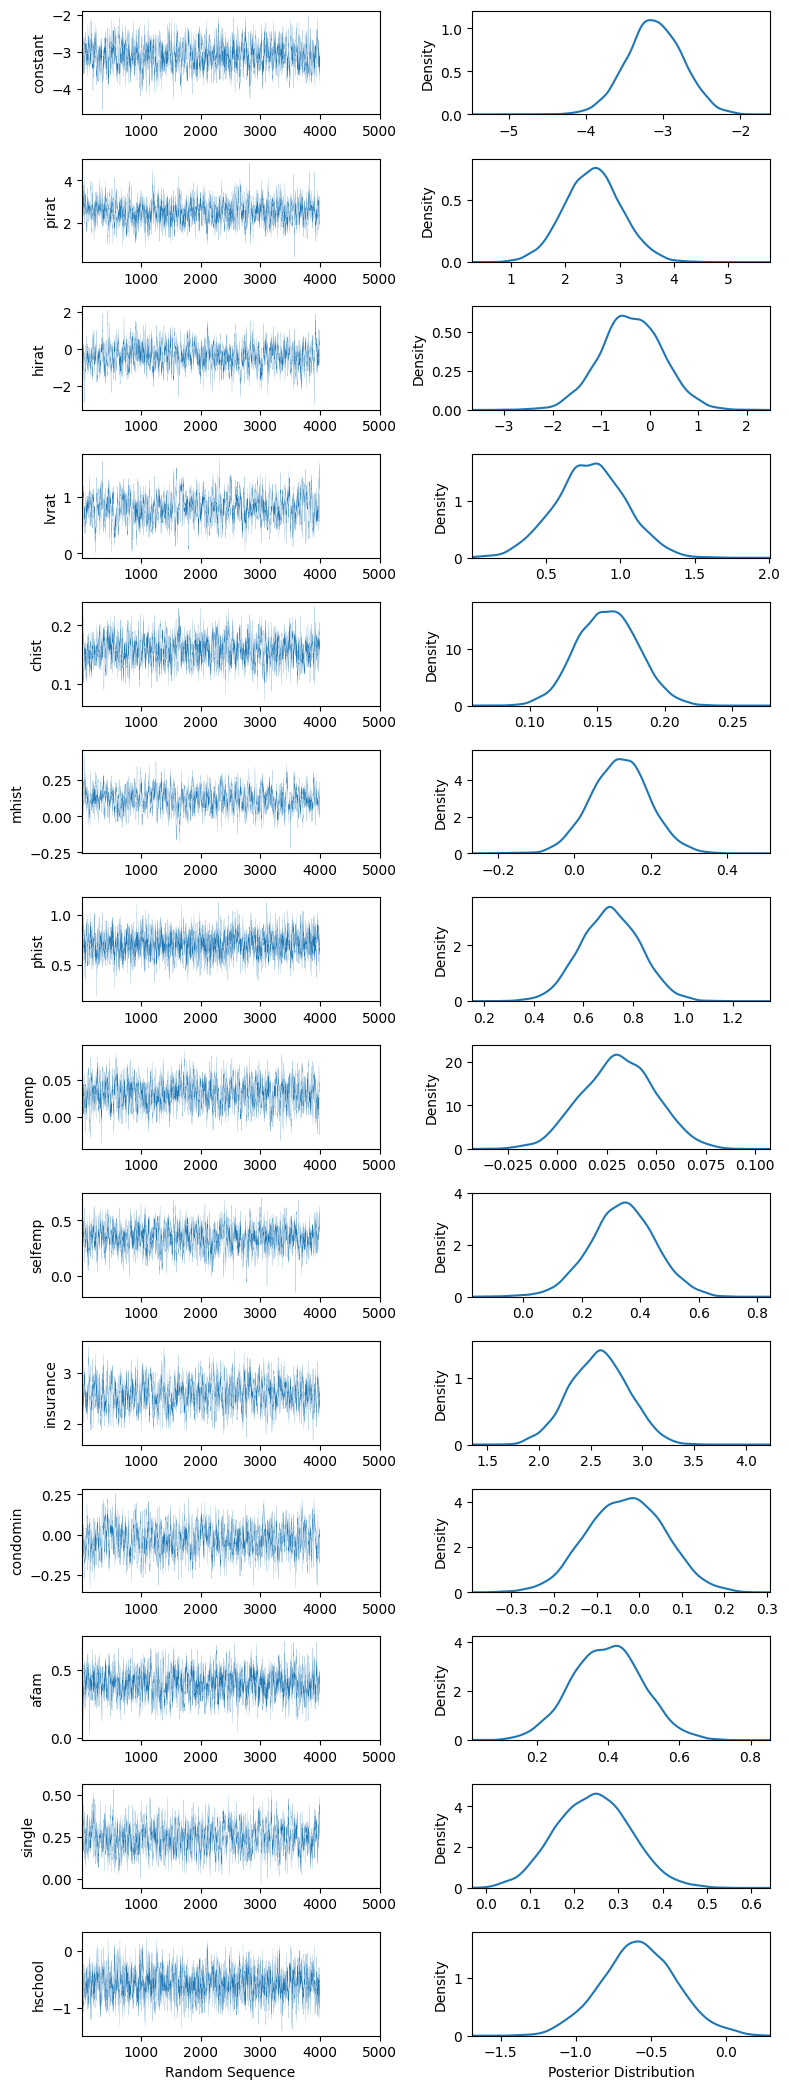

In [18]:
# Probit model of mortgage denial
np.random.seed(99)
draws = 5000
burnin = 1000
chain = 4

N, K = X.shape
beta = np.zeros(K)
Z = np.zeros(N)

# Hyperparameters for beta ~ N(0, 100 * I)
B0_inv = np.eye(K) * 0.01
b0 = np.zeros(K)

XtX = X.T @ X
V_beta = np.linalg.inv(XtX + B0_inv)
V_beta_chol = np.linalg.cholesky(V_beta)

runs_probit = np.zeros((draws, K))

for s in trange(draws, desc="Probit Gibbs Sampler"):
    # 1. Sample Z from Truncated Normal
    mu_Z = X @ beta
    fa = norm.cdf(-mu_Z)
    u = np.random.uniform(size=N)

    # If y == 1, Z > 0  -> bounds [fa, 1]
    # If y == 0, Z <= 0 -> bounds [0, fa]
    p = np.where(y == 1, fa + u * (1.0 - fa), u * fa)
    p = np.clip(p, 1e-15, 1.0 - 1e-15)
    Z = mu_Z + norm.ppf(p)

    # 2. Sample Beta vector from conditional normal posterior
    M_beta = V_beta @ (X.T @ Z)
    beta = M_beta + V_beta_chol @ np.random.normal(size=K)
    runs_probit[s, :] = beta

# Results
stats_probit = mcmc_stats(runs_probit, burnin=burnin, chain=chain, param_string=var_names, isvariance=False)
display(stats_probit)
kde_x_probit, kde_post_probit = mcmc_plots(runs_probit, burnin=burnin, param_string=var_names, isvariance=False)

Logit Gibbs Sampler: 100%|██████████| 5000/5000 [00:05<00:00, 897.63it/s]


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
constant,-6.132,0.701,-7.530,-4.780,0.020,0.011,1211.0,2000.0,1.00
pirat,4.794,1.008,2.789,6.678,0.027,0.013,1377.0,2680.0,1.00
hirat,-0.376,1.211,-2.733,1.991,0.035,0.017,1186.0,2097.0,1.00
lvrat,1.846,0.499,0.829,2.770,0.016,0.008,980.0,1718.0,1.00
chist,0.300,0.041,0.221,0.380,0.001,0.001,1354.0,2562.0,1.00
mhist,0.237,0.149,-0.045,0.535,0.004,0.002,1223.0,2005.0,1.00
phist,1.245,0.209,0.818,1.645,0.004,0.002,2352.0,3012.0,1.00
unemp,0.059,0.034,-0.010,0.123,0.001,0.000,1397.0,2071.0,1.00
selfemp,0.654,0.212,0.259,1.081,0.006,0.003,1390.0,2210.0,1.00
insurance,4.680,0.572,3.602,5.814,0.019,0.011,925.0,1373.0,1.00


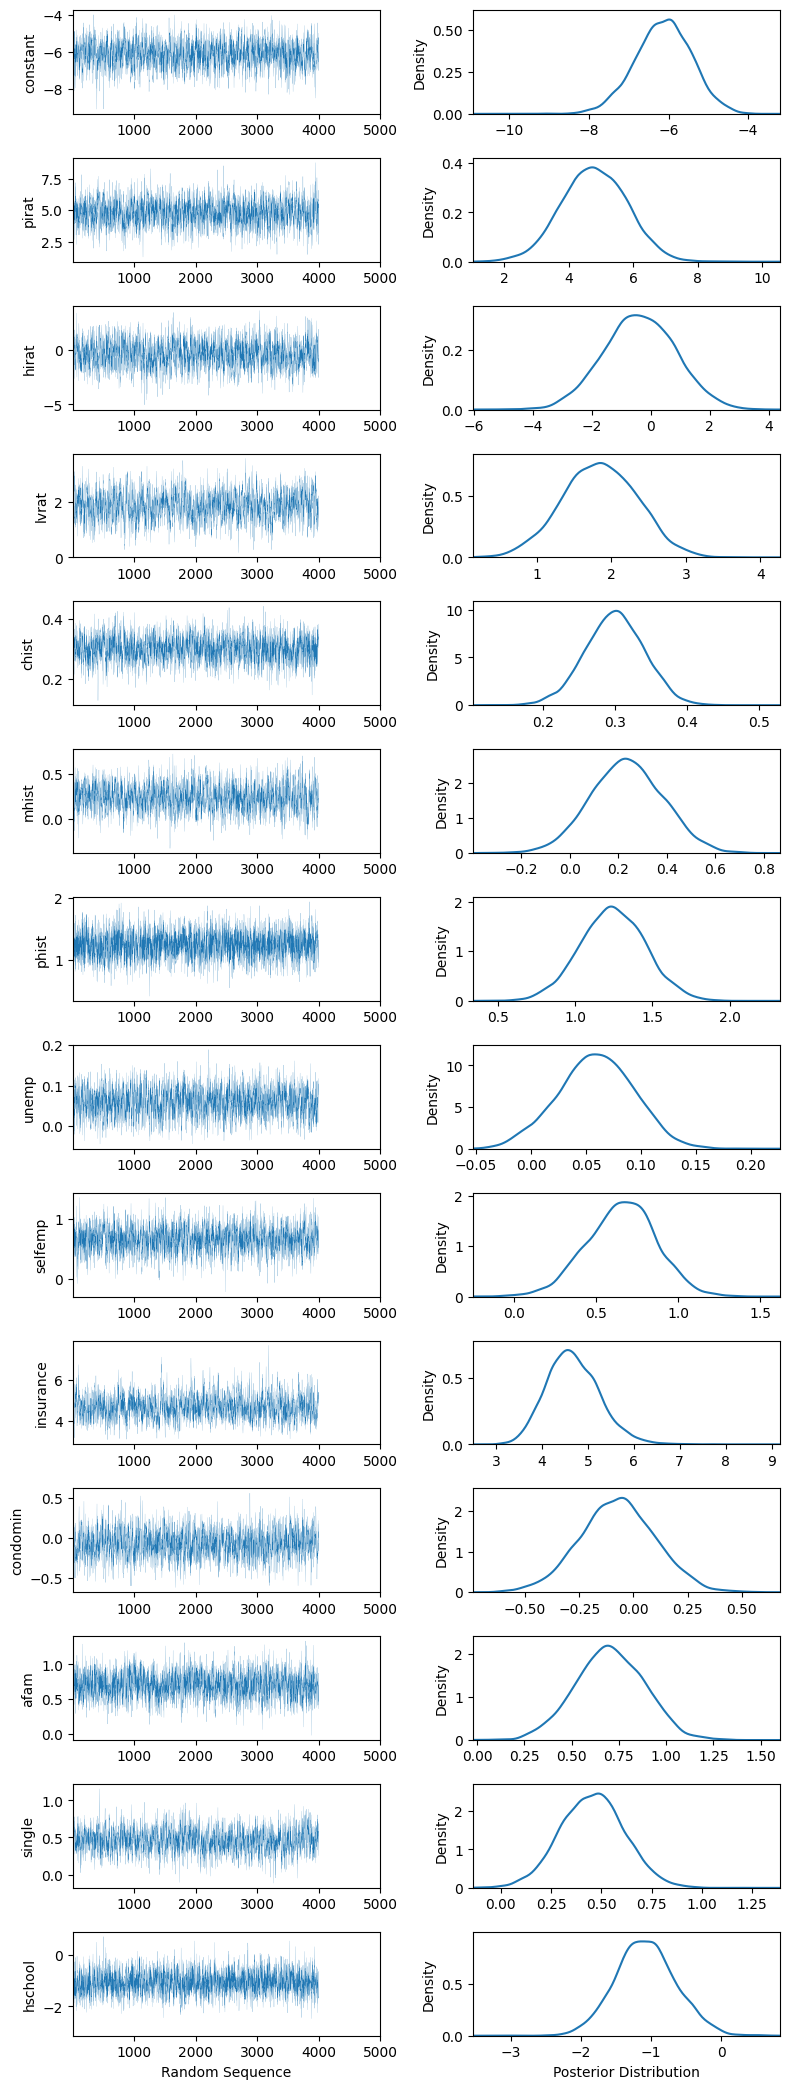

In [19]:
# Logit model of mortgage denial
kappa = y - 0.5
runs_logit = np.zeros((draws, K))

for s in trange(draws, desc="Logit Gibbs Sampler"):
    # 1. Sample omega ~ PG(1, X_i * beta)
    psi = X @ beta
    omega = random_polyagamma(np.ones(N), psi)

    # 2. Sample Beta vector from conditional normal distribution
    X_T_Omega = X.T * omega
    V_omega = np.linalg.inv(X_T_Omega @ X + B0_inv)
    m_omega = V_omega @ (X.T @ kappa)

    V_omega_chol = np.linalg.cholesky(V_omega)
    beta = m_omega + V_omega_chol @ np.random.normal(size=K)
    runs_logit[s, :] = beta

# Results
stats_logit = mcmc_stats(runs_logit, burnin=burnin, chain=chain, param_string=var_names, isvariance=False)
display(stats_logit)
kde_x_logit, kde_post_logit = mcmc_plots(runs_logit, burnin=burnin, param_string=var_names, isvariance=False)